## Double-Well model

It's a bistable stochastic dynamical system:
$$
    x_t = x_{t-1} + h\!\left(a\,x_{t-1} - b\,x_{t-1}^3\right) + \varepsilon_t,
    \quad \varepsilon_t \sim \mathcal{N}(0,\sigma^2_{\mathrm{DW}}),
$$

with parameters $a = 1$, $b = 1$, $h = 0.44$,
$\sigma_{\mathrm{DW}} = 0.63$, initial condition
$x_0 = 0.08$, and time horizon $T = 30$.

We evaluate the escape-from-origin property
$$
    \varphi_{\mathrm{DW}} = O(x > \delta) \vee O(x < -\delta),
$$
which holds at time $T$ if the trajectory has ever left a neighbourhood of
radius $\delta = 0.8$ around the unstable equilibrium at the origin, by
visiting either the positive or the negative well at least once.

In [18]:
import torch
from torch.nn.functional import threshold

from models import double_well_model, simulate, plot_traj_set

# import module optimization to use DeGAS
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

1) Monte Carlo simulations

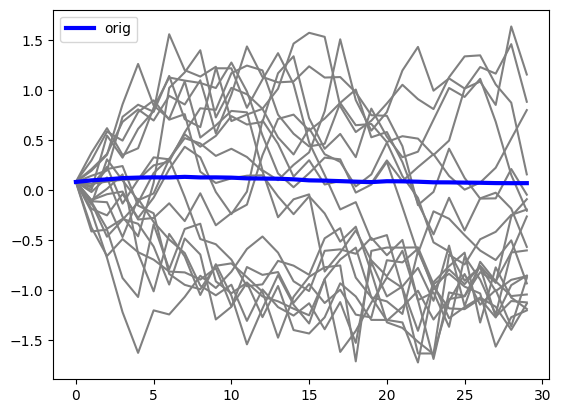

In [19]:
# logistic growth  process
# X_{t+1} = X_t + r * X_t * (1 - X_t/k)  + X_t *sqrt(k)*sigma*ep;  eps~normal(0,1)

time_steps = 30

#slower convergence to x=2, higher variance
params2 = {'time': time_steps,      # time steps
            'init_x':0.08,  # initial x
            'a': 1.0,        #noise
            'b': 1.0,        #
            'h': 0.44,    #this the sqrt of the h I would like to use
            'sigma': np.sqrt(0.4)}



trajs = simulate(double_well_model, 10000, params2)

plot_traj_set(trajs, single_traj=20, color='blue', label='orig')

In [20]:
# using trajs calculate the probability of ever exceeding 0.8 or -0.8 
exceeding_08 = (trajs > 0.8).any(dim=1).float().mean()
exceeding_m08 = (trajs < -0.8).any(dim=1).float().mean()
print("Probability of exceeding 0.8:", exceeding_08.item())
print("Probability of exceeding -0.8:", exceeding_m08.item())

# compute OR probability
exceeding_08_or_m08 = ((trajs > 0.8) | (trajs < -0.8)).any(dim=1).float().mean()
print("Probability of exceeding 0.8 or -0.8:", exceeding_08_or_m08.item())

#compute the variance of the OR probability
exceeding_08_or_m08_var = ((trajs > 0.8) | (trajs < -0.8)).any(dim=1).float().var()
print("Variance of exceeding 0.8 or -0.8:", exceeding_08_or_m08_var.item())

Probability of exceeding 0.8: 0.6208999752998352
Probability of exceeding -0.8: 0.5080999732017517
Probability of exceeding 0.8 or -0.8: 0.9900000095367432
Variance of exceeding 0.8 or -0.8: 0.009900989942252636


In [29]:
# Compute 95% confidence interval for exceeding_08_or_m08
n = trajs.shape[0]
std_error = torch.sqrt(exceeding_08_or_m08 / n)
z_score = 1.96  # for 95% confidence
ci_lower = exceeding_08_or_m08 - z_score * std_error
ci_upper = exceeding_08_or_m08 + z_score * std_error
print(f"95% confidence interval : [{ci_lower.item()}, {ci_upper.item()}]")

95% confidence interval : [0.970498263835907, 1.0095018148422241]


2) Monitor Variables

In [22]:
compiledFile = compile2SOGA('double_well.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# initial parameters
init_params = {'a':  1., 'b':1., 'h': 0.44, 'sigma': 0.4, 'xinit1':0.08, 'xinit2':-0.38, 'delta': 0.8, 'ndelta': -0.8}
params_dict = initialize_params(init_params)  

# computes SOGA output
output_dist = start_SOGA(cfg, params_dict)

T = 30
#output_dist
#plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')

# Plot the two components of the distribution
output_dist.gm.mu[0]
#plt.plot(range(T), output_dist.gm.mu[0][:T].detach(), lw=3, color='red', label='SOGA component 0')
#plt.plot(range(T), output_dist.gm.mu[1][:T].detach(), lw=3, color='orange', label='SOGA component 1')
#plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')

# Convert covariance to a 1D variance vector aligned with the mean
cov_raw = output_dist.gm.cov().detach().numpy()
if cov_raw.ndim == 2:
    cov = np.diag(cov_raw)[:T]
else:
    cov = np.squeeze(cov_raw)[:T]

mean = output_dist.gm.mean()[:T].detach().numpy()
#plt.fill_between(range(T), mean - 2 * np.sqrt(cov), mean + 2 * np.sqrt(cov), color='green', alpha=0.2, label='SOGA variance')
#plt.legend()

In [23]:
#in output_dist.var_list get the index of var 'phi'
phi_index = output_dist.var_list.index('phi')
print("phi index:", phi_index)

print("Mean of phi:", output_dist.gm.mean()[phi_index])

#variance of phi
print("Variance of phi:", output_dist.gm.cov()[phi_index, phi_index])

phi index: 0
Mean of phi: tensor(0.9418, grad_fn=<SelectBackward0>)
Variance of phi: tensor(0.0549, grad_fn=<SelectBackward0>)


In [24]:
# Let's see also phipos and phineg:
phipos_index = output_dist.var_list.index('phipos')
print("phipos index:", phipos_index)

print("Mean of phipos:", output_dist.gm.mean()[phipos_index])

phineg_index = output_dist.var_list.index('phineg')
print("phineg index:", phineg_index)
print("Mean of phineg:", output_dist.gm.mean()[phineg_index])


phipos index: 2
Mean of phipos: tensor(0.5395, grad_fn=<SelectBackward0>)
phineg index: 3
Mean of phineg: tensor(0.4023, grad_fn=<SelectBackward0>)


3) Direct Integration

In [25]:
compiledFile = compile2SOGA('double_well_DI.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# initial parameters
init_params = {'a':  1., 'b':1., 'h': 0.44, 'sigma': 0.4, 'xinit1':0.08, 'xinit2':-0.38, 'delta': 0.8, 'ndelta': -0.8}
params_dict = initialize_params(init_params)  

# computes SOGA output
output_dist = start_SOGA(cfg, params_dict)

In [26]:

from libSOGAshared import ghk_mvnorm_prob

# Probability that ALL time steps stay within [-0.8, 0.8]
lower, upper = -0.8, 0.8
all_time_idx = list(range(T))
idx_tensor = torch.tensor(all_time_idx)
A = torch.full((T,), lower, dtype=output_dist.gm.mu.dtype, device=output_dist.gm.mu.device)
B = torch.full((T,), upper, dtype=output_dist.gm.mu.dtype, device=output_dist.gm.mu.device)

prob_stays_within = torch.zeros((), dtype=output_dist.gm.mu.dtype, device=output_dist.gm.mu.device)
for k in range(output_dist.gm.n_comp()):
    mu_k = output_dist.gm.mu[k, all_time_idx]
    sigma_k = output_dist.gm.sigma[k][idx_tensor.unsqueeze(1), idx_tensor]
    prob_k = ghk_mvnorm_prob(mu_k, sigma_k, A, B)
    prob_stays_within = prob_stays_within + output_dist.gm.pi[k].squeeze() * prob_k

# P(exceeds 0.8 or -0.8)
prob_exceeds = 1.0 - prob_stays_within

print("=== Using ghk_mvnorm_prob (exact) ===")
print(f"P(stays in [-0.8, 0.8] for all time) = {prob_stays_within.item():.6f}")
print(f"P(exceeds 0.8 or -0.8) = {prob_exceeds.item():.6f}")
print("\n=== Comparison with Monte Carlo ===")
print(f"P(exceeds 0.8 or -0.8) via MC = {exceeding_08_or_m08.item():.6f}")
print(f"Difference: {abs(prob_exceeds.item() - exceeding_08_or_m08.item()):.6f}")


=== Using ghk_mvnorm_prob (exact) ===
P(stays in [-0.8, 0.8] for all time) = 0.007265
P(exceeds 0.8 or -0.8) = 0.992735

=== Comparison with Monte Carlo ===
P(exceeds 0.8 or -0.8) via MC = 0.990000
Difference: 0.002735


In [38]:
import botorch.utils.probability.mvnxpb as mvn

# Compute P(reaches 0.8) and P(reaches -0.8) using MVNXPB, following libSOGAshared
all_time_idx = list(range(T))
idx_tensor = torch.tensor(all_time_idx)

# P(reaches 0.8 at some point) = 1 - P(all X_t <= 0.8)
prob_never_reaches_08 = torch.zeros((), dtype=output_dist.gm.mu.dtype, device=output_dist.gm.mu.device)
for k in range(output_dist.gm.n_comp()):
    mu_k = output_dist.gm.mu[k, all_time_idx]
    sigma_k = output_dist.gm.sigma[k][idx_tensor.unsqueeze(1), idx_tensor]
    bounds = torch.stack([
        torch.tensor([-torch.inf, 0.8 - mu_k[i]], dtype=mu_k.dtype, device=mu_k.device)
        for i in range(mu_k.numel())
    ])
    result = torch.exp(mvn.MVNXPB(covariance_matrix=sigma_k, bounds=bounds).solve())
    if torch.isnan(result):
        sigma_k = (sigma_k + sigma_k.T) / 2
        result = torch.exp(mvn.MVNXPB(covariance_matrix=sigma_k, bounds=bounds).solve())
    prob_never_reaches_08 = prob_never_reaches_08 + output_dist.gm.pi[k].squeeze() * result

prob_reaches_08 = 1.0 - prob_never_reaches_08

# P(reaches -0.8 at some point) = 1 - P(all X_t >= -0.8)
prob_never_reaches_m08 = torch.zeros((), dtype=output_dist.gm.mu.dtype, device=output_dist.gm.mu.device)
for k in range(output_dist.gm.n_comp()):
    mu_k = output_dist.gm.mu[k, all_time_idx]
    sigma_k = output_dist.gm.sigma[k][idx_tensor.unsqueeze(1), idx_tensor]
    bounds = torch.stack([
        torch.tensor([-0.8 - mu_k[i], torch.inf], dtype=mu_k.dtype, device=mu_k.device)
        for i in range(mu_k.numel())
    ])
    result = torch.exp(mvn.MVNXPB(covariance_matrix=sigma_k, bounds=bounds).solve())
    if torch.isnan(result):
        sigma_k = (sigma_k + sigma_k.T) / 2
        result = torch.exp(mvn.MVNXPB(covariance_matrix=sigma_k, bounds=bounds).solve())
    prob_never_reaches_m08 = prob_never_reaches_m08 + output_dist.gm.pi[k].squeeze() * result

prob_reaches_m08 = 1.0 - prob_never_reaches_m08

print("=== Reaches Properties (phi_pos and phi_neg) via MVNXPB ===")
print(f"P(reaches 0.8 at some point) = {prob_reaches_08.item():.6f}")
print(f"P(reaches -0.8 at some point) = {prob_reaches_m08.item():.6f}")
print(f"P(reaches 0.8 OR -0.8) = {prob_exceeds.item():.6f}")
print(f"\n=== Comparison with Monte Carlo ===")
print(f"P(exceeds 0.8 or -0.8) via MC = {exceeding_08_or_m08.item():.6f}")


=== Reaches Properties (phi_pos and phi_neg) via MVNXPB ===
P(reaches 0.8 at some point) = 0.533417
P(reaches -0.8 at some point) = 0.518175
P(reaches 0.8 OR -0.8) = 0.992735

=== Comparison with Monte Carlo ===
P(exceeds 0.8 or -0.8) via MC = 0.990000


OPTIMIZATION

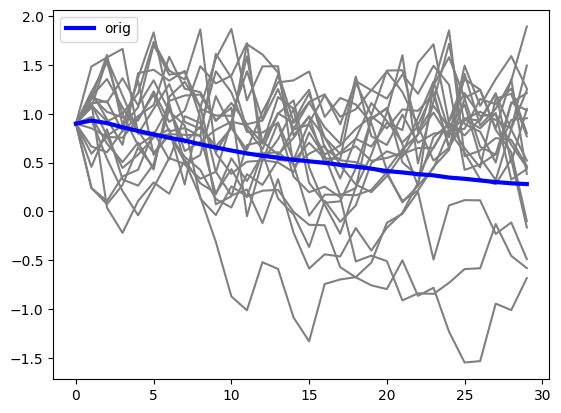

In [15]:
#slower convergence to x=2, higher variance
params2 = {'time': time_steps,      # time steps
            'init_x':0.9,  # initial x
            'a': 1.0,        #noise
            'b': 1.0,        #
            'h': 0.44,    #this the sqrt of the h I would like to use
            'sigma': np.sqrt(0.5)}



trajs = simulate(double_well_model, 10000, params2)

plot_traj_set(trajs, single_traj=20, color='blue', label='orig')

In [16]:
# using traj, what is the probability of ever exceeding -0.8
exceeding_m08 = (trajs < -0.8).any(dim=1).float().mean()
print("Probability of exceeding -0.8:", exceeding_m08.item())

Probability of exceeding -0.8: 0.3107999861240387


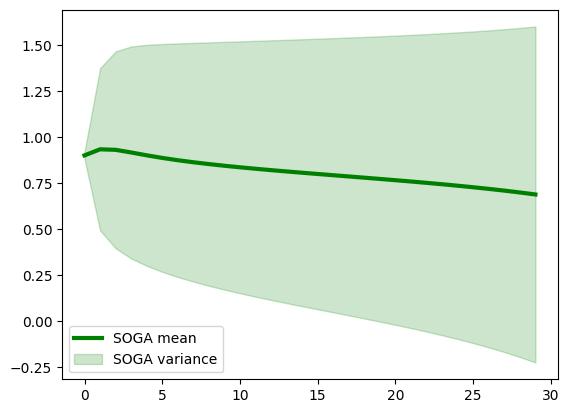

In [8]:
compiledFile = compile2SOGA('double_well_opt.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# initial parameters
init_params = {'a':  1., 'b':1., 'h': 0.44, 'sigma': 0.5, 'xinit1':0.9,'ndelta': -0.8}
params_dict = initialize_params(init_params)  

# computes SOGA output
output_dist = start_SOGA(cfg, params_dict)

T = 30
#output_dist
#plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')

# Plot the two components of the distribution
output_dist.gm.mu[0]
#plt.plot(range(T), output_dist.gm.mu[0][:T].detach(), lw=3, color='red', label='SOGA component 0')
#plt.plot(range(T), output_dist.gm.mu[1][:T].detach(), lw=3, color='orange', label='SOGA component 1')
plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')

# Convert covariance to a 1D variance vector aligned with the mean
cov_raw = output_dist.gm.cov().detach().numpy()
if cov_raw.ndim == 2:
    cov = np.diag(cov_raw)[:T]
else:
    cov = np.squeeze(cov_raw)[:T]

mean = output_dist.gm.mean()[:T].detach().numpy()
plt.fill_between(range(T), mean - 2 * np.sqrt(cov), mean + 2 * np.sqrt(cov), color='green', alpha=0.2, label='SOGA variance')
plt.legend()

In [9]:
print(output_dist.gm.mean()[output_dist.var_list.index('phineg')])
print(output_dist.gm.cov()[output_dist.var_list.index('phineg'), output_dist.var_list.index('phineg')])

tensor(0.0026, grad_fn=<SelectBackward0>)
tensor(0.0026, grad_fn=<SelectBackward0>)


In [14]:
target = 0.5
idx = output_dist.var_list.index('phineg')  # or 'phineg' if that's your variable

loss = lambda output_dist: (output_dist.gm.mean()[idx] - target)**2
loss(output_dist)

tensor(2.0651e-09, grad_fn=<PowBackward0>)

In [11]:

cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

init_params = {'a':  1., 'b':1., 'h': 0.44, 'sigma': 0.5, 'xinit1':0.9,'ndelta': -0.8}
params_dict = initialize_params(init_params) 

#set some parameters to be non-optimizable 
#we want to optimize the noise 
params_dict['a'].requires_grad = False
params_dict['b'].requires_grad = False
params_dict['h'].requires_grad = False
params_dict['xinit1'].requires_grad = False
params_dict['ndelta'].requires_grad = False


# gradient based optimization
loss_list = optimize(cfg, params_dict, loss, n_steps=200, lr=0.05)

# print results:
for key, value in params_dict.items():
    print(f"{key}: {value.item()}")


a: 1.0 b: 1.0 h: 0.44 sigma: 0.5499999986921618 xinit1: 0.9 ndelta: -0.8  loss: 0.24743595826026954
a: 1.0 b: 1.0 h: 0.44 sigma: 0.5914362247585098 xinit1: 0.9 ndelta: -0.8  loss: 0.127820545248884
a: 1.0 b: 1.0 h: 0.44 sigma: 0.6334869912464237 xinit1: 0.9 ndelta: -0.8  loss: 0.049400030791505636
a: 1.0 b: 1.0 h: 0.44 sigma: 0.6722066520953883 xinit1: 0.9 ndelta: -0.8  loss: 0.0154776631903975
a: 1.0 b: 1.0 h: 0.44 sigma: 0.7064525347407857 xinit1: 0.9 ndelta: -0.8  loss: 0.0029033987973831558
a: 1.0 b: 1.0 h: 0.44 sigma: 0.73599905562177 xinit1: 0.9 ndelta: -0.8  loss: 1.6386580560220654e-06
a: 1.0 b: 1.0 h: 0.44 sigma: 0.7609695191211362 xinit1: 0.9 ndelta: -0.8  loss: 0.0015048766795400226
a: 1.0 b: 1.0 h: 0.44 sigma: 0.7816269612048639 xinit1: 0.9 ndelta: -0.8  loss: 0.004845430246224675
a: 1.0 b: 1.0 h: 0.44 sigma: 0.7982853554966267 xinit1: 0.9 ndelta: -0.8  loss: 0.008706619964760897
a: 1.0 b: 1.0 h: 0.44 sigma: 0.811268821956068 xinit1: 0.9 ndelta: -0.8  loss: 0.01240335644773

In [12]:
output_dist = start_SOGA(cfg, params_dict)

print(output_dist.gm.mean()[output_dist.var_list.index('phineg')])
print(output_dist.gm.cov()[output_dist.var_list.index('phineg'), output_dist.var_list.index('phineg')])

tensor(0.5000, grad_fn=<SelectBackward0>)
tensor(0.2500, grad_fn=<SelectBackward0>)


Probability of exceeding -0.8: 0.45210000872612


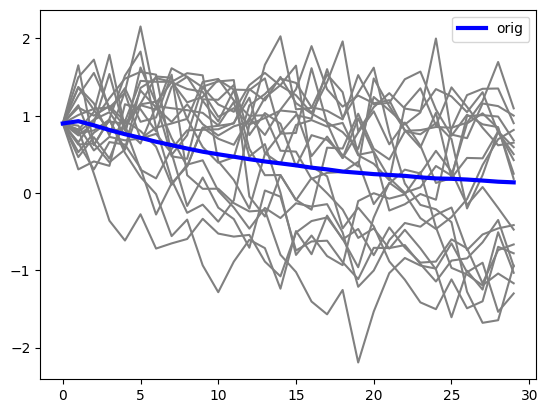

In [17]:
#slower convergence to x=2, higher variance
params2 = {'time': time_steps,      # time steps
            'init_x':0.9,  # initial x
            'a': 1.0,        #noise
            'b': 1.0,        #
            'h': 0.44,    #this the sqrt of the h I would like to use
            'sigma': np.sqrt(0.70738)}



trajs = simulate(double_well_model, 10000, params2)

plot_traj_set(trajs, single_traj=20, color='blue', label='orig')

# using traj, what is the probability of ever exceeding -0.8
exceeding_m08 = (trajs < -0.8).any(dim=1).float().mean()
print("Probability of exceeding -0.8:", exceeding_m08.item())